# Détection de deepfakes — Data Science & Baseline ML

Dataset : [`xhlulu/140k-real-and-fake-faces`](https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces)

L'objectif de ce notebook est de construire une première solution de détection de deepfakes à partir
d'images de visages. On commence par comprendre le jeu de données, vérifier sa qualité, créer une
baseline de machine learning classique, puis analyser ses performances et ses limites.

Le jeu de données réunit 70 000 vrais visages (la base FFHQ, des photos Flickr rassemblées par
NVIDIA) et 70 000 faux visages produits par StyleGAN. C'est un point important : les deux classes
sont de vrais visages, le modèle doit donc apprendre les petits défauts laissés par la génération
et non une différence grossière de style.

Une réserve à garder en tête dès le départ : comme tous les faux viennent d'un seul générateur
(StyleGAN), la tâche reste relativement abordable, et rien ne garantit que le modèle reconnaisse
des faux produits autrement (diffusion, échange de visages en vidéo, etc.).

Ce notebook couvre donc la première étape du projet : données, exploration, préparation, baseline
régularisée et diagnostic biais/variance.

## 1. Dépendances et imports

In [ ]:
# Installation si nécessaire (décommenter au besoin)
# !pip install kagglehub pandas numpy matplotlib scikit-learn pillow tqdm

import warnings, random, hashlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Machine Learning classique ---
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)

# Fonctions métier externalisées pour garder le notebook lisible et modulaire
from partie1_utils import (
    IMG_EXT,
    augment_training_set,
    class_dir,
    compute_balanced_class_weight,
    count_images,
    find_split_dirs,
    image_feature_table,
    load_split,
    show_grid,
    to_flat_features,
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
print("Imports OK — pandas", pd.__version__)

# Données et machine learning classique

## 2. Choix du dataset

Le sujet demande de partir d'une image pour décider si elle est vraie ou truquée. Il nous faut donc
un jeu d'images étiquetées, équilibré entre les deux classes, assez gros pour entraîner un modèle,
et surtout sans piège qui rendrait la tâche trop facile.

On a d'abord essayé le dataset `deepfake-detection-2026`, qu'on a fini par écarter : ses images
"fake" étaient en réalité des avatars dessinés (dicebear, multiavatar) opposés à des photos. Un
classifieur y atteignait 98 % d'accuracy simplement en distinguant une photo d'un dessin, ce qui n'a
rien à voir avec de la détection de deepfakes. C'est une fuite de données déguisée.

Le jeu `140k Real and Fake Faces` corrige ce défaut. Il oppose de vrais visages (FFHQ) à des faux
générés par StyleGAN : des deux côtés, ce sont des visages, et le modèle doit vraiment repérer les
traces de génération. Il est volumineux (70 000 images par classe), parfaitement équilibré, et déjà
découpé en train / validation / test sous forme de dossiers d'images, ce qui simplifie la mise en
place.

### Téléchargement du dataset (kagglehub)

In [2]:
import kagglehub

# Télécharge (et met en cache) le dataset depuis Kaggle (~4 Go la 1re fois)
dataset_dir = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")
print("Dataset téléchargé dans :", dataset_dir)

Dataset téléchargé dans : C:\Users\pauls\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2


## 3. Repérage des dossiers d'images

Le dataset range les images dans des dossiers `train`, `valid` et `test`, chacun contenant un
sous-dossier `real` et un sous-dossier `fake`. On les retrouve automatiquement, peu importe la
profondeur d'imbrication, puis on compte les images disponibles dans chacun.

In [3]:
split_dirs = find_split_dirs(dataset_dir)
counts = {s: {cls: count_images(class_dir(sd, cls)) for cls in ("real", "fake")}
          for s, sd in split_dirs.items()}
counts_df = pd.DataFrame(counts).T.reindex(["train", "val", "test"])[["real", "fake"]]

print("Dossiers détectés :")
for s in ["train", "val", "test"]:
    print(f"  {s:5s}:", split_dirs.get(s, "—"))
print()
print(counts_df)

Dossiers détectés :
  train: C:\Users\pauls\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2\real_vs_fake\real-vs-fake\train
  val  : C:\Users\pauls\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2\real_vs_fake\real-vs-fake\valid
  test : C:\Users\pauls\.cache\kagglehub\datasets\xhlulu\140k-real-and-fake-faces\versions\2\real_vs_fake\real-vs-fake\test

        real   fake
train  50000  50000
val    10000  10000
test   10000  10000


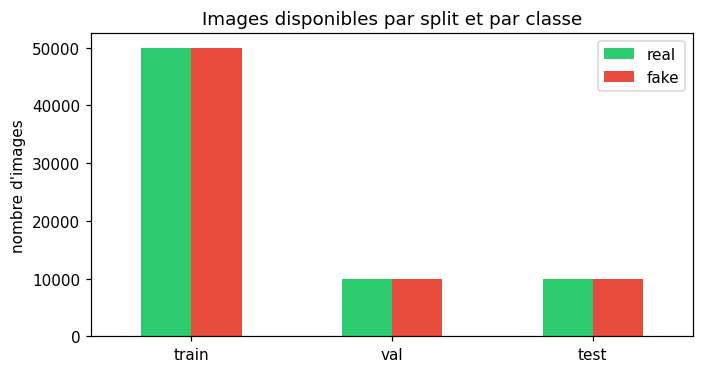

In [4]:
# Nombre d'images disponibles par split et par classe
ax = counts_df.plot.bar(color={"real": "#2ecc71", "fake": "#e74c3c"},
                        figsize=(6.5, 3.5), rot=0)
ax.set_title("Images disponibles par split et par classe")
ax.set_ylabel("nombre d'images"); ax.set_xlabel("")
plt.tight_layout(); plt.show()

## 4. Chargement des images

Les images sont déjà sur le disque, il n'y a donc rien à télécharger image par image. On charge
un échantillon de chaque classe pour chaque split : les 140 000 images complètes ne tiendraient pas
en mémoire, et un sous-ensemble suffit largement pour ce travail. Les paramètres `N_*_PER_CLASS` se
règlent selon la RAM et le temps disponibles. Chaque image est convertie en RGB et redimensionnée
en `IMG_SIZE × IMG_SIZE`, et une barre de progression suit le chargement.

In [ ]:
IMG_SIZE = 128                 # côté des images (carré)
N_TRAIN_PER_CLASS = 1500       # images chargées PAR classe pour l'entraînement (↑ = mieux, + long)
N_VAL_PER_CLASS   = 300
N_TEST_PER_CLASS  = 300

In [6]:
print("Chargement des images depuis les dossiers locaux...")
X_train, y_train = load_split(split_dirs["train"], N_TRAIN_PER_CLASS)
X_val,   y_val   = load_split(split_dirs["val"],   N_VAL_PER_CLASS)
X_test,  y_test  = load_split(split_dirs["test"],  N_TEST_PER_CLASS)

print("Train :", X_train.shape, "| Val :", X_val.shape, "| Test :", X_test.shape)
print("Répartition train [FAKE, REAL] :", np.bincount(y_train))

Chargement des images depuis les dossiers locaux...


train/real:   0%|          | 0/1500 [00:00<?, ?it/s]

train/fake:   0%|          | 0/1500 [00:00<?, ?it/s]

valid/real:   0%|          | 0/300 [00:00<?, ?it/s]

valid/fake:   0%|          | 0/300 [00:00<?, ?it/s]

test/real:   0%|          | 0/300 [00:00<?, ?it/s]

test/fake:   0%|          | 0/300 [00:00<?, ?it/s]

Train : (3000, 128, 128, 3) | Val : (600, 128, 128, 3) | Test : (600, 128, 128, 3)
Répartition train [FAKE, REAL] : [1500 1500]


## 5. Analyse exploratoire (EDA)

Avant de modéliser, on regarde un peu les données chargées (toujours avant augmentation) : quelques
statistiques par classe, une vérification des images douteuses, et enfin un aperçu visuel.

### 5.1 Statistiques descriptives

On résume chaque image par quelques chiffres simples : son intensité moyenne, son contraste et la
moyenne de chaque canal de couleur. En comparant ces distributions entre REAL et FAKE, on voit si
un indice global évident sépare les deux classes (en pratique, les statistiques sont très proches,
ce qui annonce déjà qu'un modèle linéaire aura du mal).

Moyennes des descripteurs par classe :
       intensite_moy  contraste           R           G          B
label                                                             
FAKE      112.260002  60.639999  132.410004  108.220001  96.139999
REAL      113.970001  62.529999  134.660004  109.660004  97.589996

Écart-type des descripteurs par classe :
       intensite_moy  contraste
label                          
FAKE       26.860001      10.45
REAL       27.170000       9.76


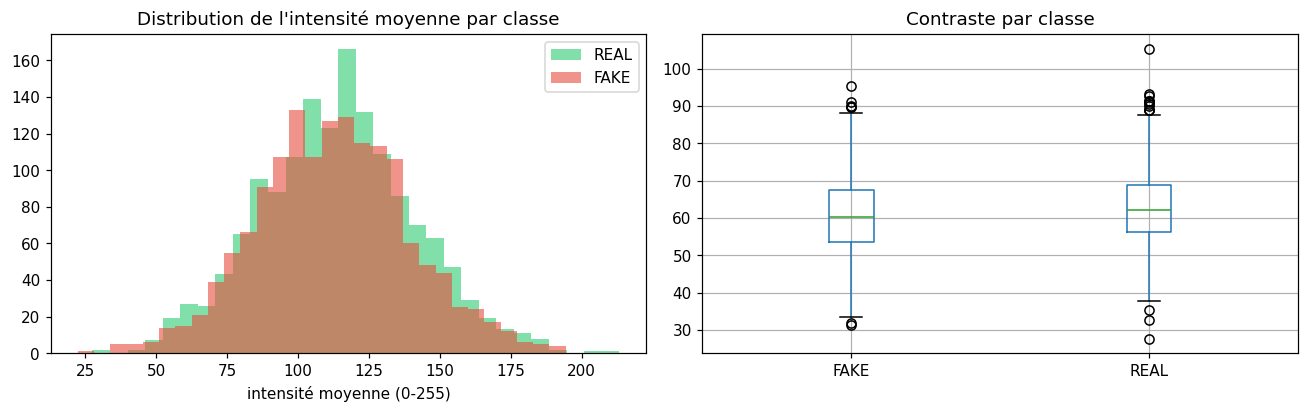

In [7]:
feat = image_feature_table(X_train, y_train)
print("Moyennes des descripteurs par classe :")
print(feat.groupby("label")[["intensite_moy", "contraste", "R", "G", "B"]].mean().round(2))
print("\nÉcart-type des descripteurs par classe :")
print(feat.groupby("label")[["intensite_moy", "contraste"]].std().round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for lab, col in [("REAL", "#2ecc71"), ("FAKE", "#e74c3c")]:
    ax[0].hist(feat.loc[feat.label == lab, "intensite_moy"], bins=30,
               alpha=0.6, label=lab, color=col)
ax[0].set_title("Distribution de l'intensité moyenne par classe")
ax[0].set_xlabel("intensité moyenne (0-255)"); ax[0].legend()
feat.boxplot(column="contraste", by="label", ax=ax[1])
ax[1].set_title("Contraste par classe"); ax[1].set_xlabel(""); plt.suptitle("")
plt.tight_layout(); plt.show()

### 5.2 Détection d'anomalies

On vérifie que les données sont saines : images presque uniformes (souvent un signe de fichier vide
ou corrompu), images quasiment en niveaux de gris, doublons exacts, et valeurs d'intensité
aberrantes repérées avec la règle de l'écart interquartile. On termine par un coup d'œil aux images
les plus sombres et les plus claires pour s'assurer qu'il ne s'agit pas de cas problématiques.

Images analysées                           : 3000
Images quasi-uniformes (vides/corrompues)  : 0
Images quasi en niveaux de gris            : 0
Doublons exacts                            : 0
Outliers d'intensité (règle IQR)           : 23


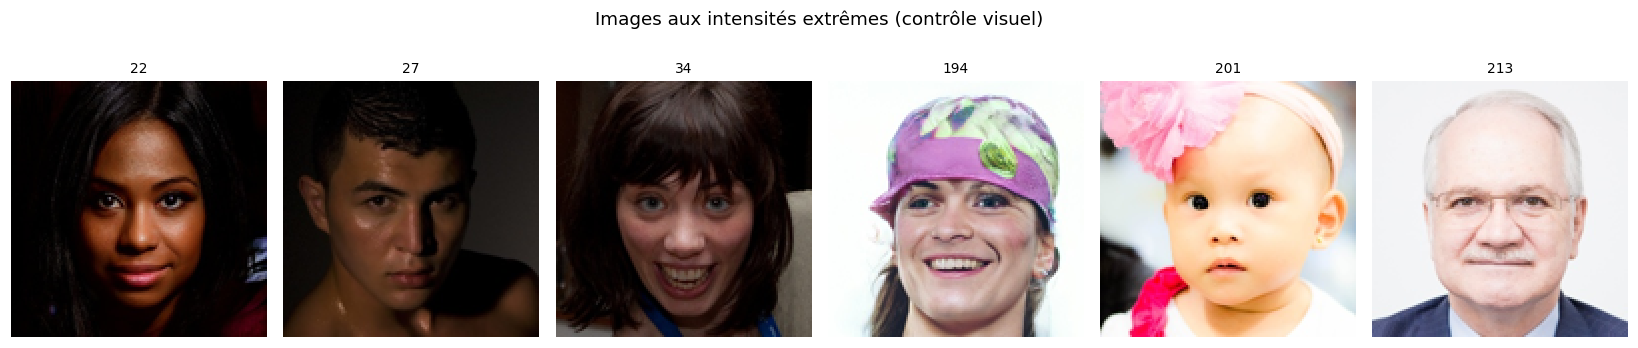

In [8]:
flat = X_train.reshape(len(X_train), -1).astype("float32")
std_per_img = flat.std(axis=1)
mean_per_img = flat.mean(axis=1)

# 1) Images quasi-uniformes (potentiellement vides / corrompues)
blank = np.where(std_per_img < 5)[0]
# 2) Images quasi en niveaux de gris (faible écart entre canaux R, G, B)
chan_spread = X_train.astype("float32").std(axis=3).mean(axis=(1, 2))
grayscale = np.where(chan_spread < 3)[0]
# 3) Doublons exacts (hash des pixels)
seen, dups = {}, []
for i in range(len(X_train)):
    h = hashlib.md5(X_train[i].tobytes()).hexdigest()
    dups.append(i) if h in seen else seen.update({h: i})
# 4) Valeurs extrêmes d'intensité (méthode IQR)
q1, q3 = np.percentile(mean_per_img, [25, 75]); iqr = q3 - q1
outliers = np.where((mean_per_img < q1 - 1.5*iqr) | (mean_per_img > q3 + 1.5*iqr))[0]

print(f"Images analysées                           : {len(X_train)}")
print(f"Images quasi-uniformes (vides/corrompues)  : {len(blank)}")
print(f"Images quasi en niveaux de gris            : {len(grayscale)}")
print(f"Doublons exacts                            : {len(dups)}")
print(f"Outliers d'intensité (règle IQR)           : {len(outliers)}")

# Visualisation de quelques cas extrêmes (les + sombres / + clairs)
extremes = np.concatenate([mean_per_img.argsort()[:3], mean_per_img.argsort()[-3:]])
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
fig.suptitle("Images aux intensités extrêmes (contrôle visuel)", y=1.05)
for ax, i in zip(axes, extremes):
    ax.imshow(X_train[i]); ax.axis("off")
    ax.set_title(f"{mean_per_img[i]:.0f}", fontsize=9)
plt.tight_layout(); plt.show()

### 5.3 Visualisation d'exemples

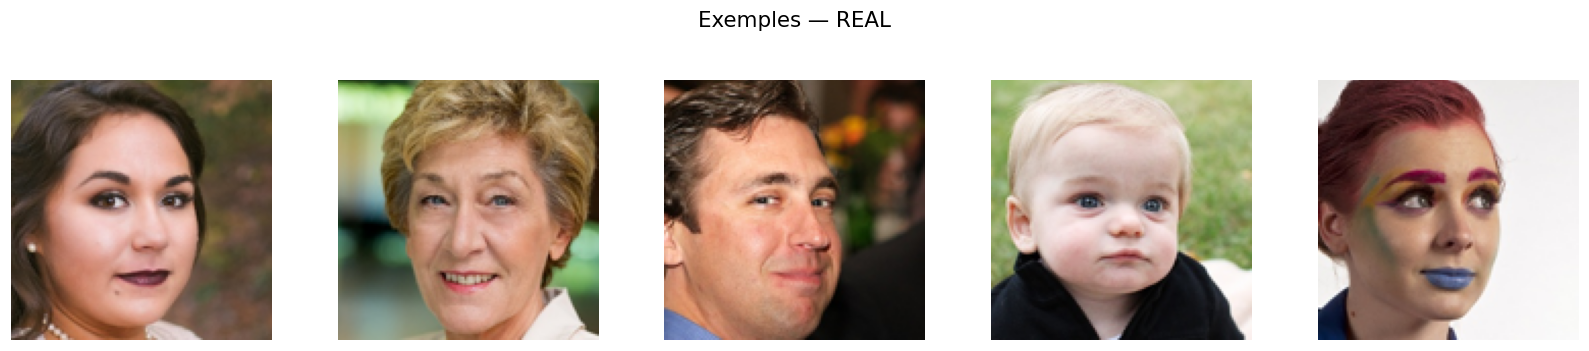

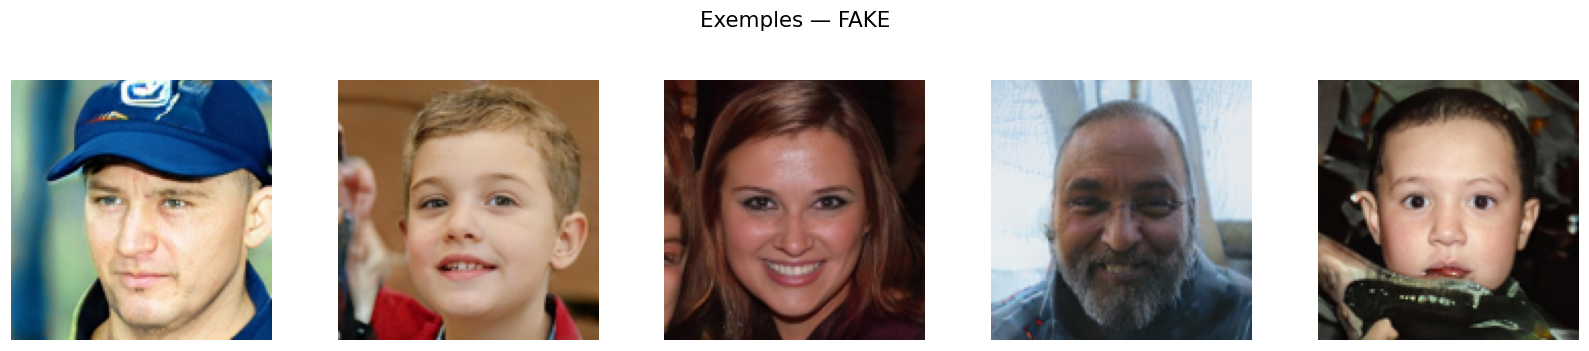

In [9]:
show_grid(X_train, y_train, 1, "REAL", plt_module=plt)
show_grid(X_train, y_train, 0, "FAKE", plt_module=plt)

## 6. Préparation des données

Les trois jeux train, validation et test viennent directement du dataset (dossiers séparés), il n'y
a donc pas de découpage à refaire. On augmente ensuite uniquement le jeu d'entraînement : la
validation et le test restent des images intactes, sinon les scores seraient trompeurs.

In [10]:
# Récapitulatif des jeux fournis par le dataset
print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")
print("Train [FAKE, REAL] :", np.bincount(y_train))
print("Val   [FAKE, REAL] :", np.bincount(y_val))
print("Test  [FAKE, REAL] :", np.bincount(y_test))

Train : 3000 | Val : 600 | Test : 600
Train [FAKE, REAL] : [1500 1500]
Val   [FAKE, REAL] : [300 300]
Test  [FAKE, REAL] : [300 300]


### 6.1 Augmentation du jeu d'entraînement

Pour donner plus de matière au modèle, on fabrique plusieurs variantes de chaque image
d'entraînement. Chacune reste réaliste mais introduit une petite perturbation, ce qui pousse le
modèle à devenir plus robuste : miroir horizontal, variations de luminosité, de contraste et de
couleur, compression JPEG agressive (comme après un partage sur le web), bruit de capteur, léger
flou et petite rotation. Avec `AUG_PER_IMAGE` variantes par image, le jeu d'entraînement est
multiplié par `1 + AUG_PER_IMAGE`.

In [11]:
AUG_PER_IMAGE = 5      # nb de variantes générées par image -> dataset x(1 + AUG_PER_IMAGE)

# Sauvegarde du train NON augmenté (servira à la baseline ML sans fuite par doublons)
X_train_raw, y_train_raw = X_train.copy(), y_train.copy()

n_before = len(X_train)
X_train, y_train = augment_training_set(X_train, y_train, AUG_PER_IMAGE, img_size=IMG_SIZE)
print(f"Train : {n_before} -> {len(X_train)} images après augmentation "
      f"(x{len(X_train)/max(n_before,1):.1f})")
print("Répartition train [FAKE, REAL] :", np.bincount(y_train))

# Poids de classe calculés sur le train augmenté
class_weight = compute_balanced_class_weight(y_train)
print("Poids de classe :", class_weight)

Augmentation:   0%|          | 0/3000 [00:00<?, ?it/s]

Train : 3000 -> 18000 images après augmentation (x6.0)
Répartition train [FAKE, REAL] : [9000 9000]
Poids de classe : {0: 1.0, 1: 1.0}


## 7. Un modèle de machine learning classique

Pour établir une référence solide, on entraîne un modèle simple : une régression logistique sur les
pixels aplatis d'images réduites à 32×32. On l'entraîne sur le jeu d'entraînement non augmenté, pour
éviter que des variantes quasi identiques ne se retrouvent à la fois en apprentissage et en
validation croisée.

C'est aussi l'occasion d'illustrer la régularisation. En classification, la régression logistique
pénalisée correspond directement à Ridge, Lasso et ElasticNet. La pénalité L2 (Ridge) rétrécit tous
les coefficients sans jamais les annuler, ce qui stabilise le modèle. La pénalité L1 (Lasso) en met
beaucoup à zéro et réalise donc une sélection de variables, le modèle devient creux. ElasticNet
combine les deux et offre un compromis. Dans scikit-learn, le paramètre C est l'inverse de la
force de régularisation : plus C est petit, plus on régularise. On compare les trois et on
regarde la sparsité (le nombre de coefficients non nuls) que chacune produit.

In [12]:
ML_SIZE = 32   # images réduites pour le ML : 32x32x3 = 3072 features

# Train NON augmenté (pas de doublons) + test
Xtr_flat = to_flat_features(X_train_raw, size=ML_SIZE)
Xte_flat = to_flat_features(X_test, size=ML_SIZE)
print("Features ML :", Xtr_flat.shape, "| test :", Xte_flat.shape)

# Comparaison des régularisations (équivalents classification de Ridge / Lasso / ElasticNet)
reg_configs = [
    ("Ridge (L2)",  dict(penalty="l2",         solver="liblinear")),
    ("Lasso (L1)",  dict(penalty="l1",         solver="liblinear")),
    ("ElasticNet",  dict(penalty="elasticnet", solver="saga", l1_ratio=0.5, max_iter=2000)),
]

rows, fitted = [], {}
for name, params in reg_configs:
    print(f"Config : {name, params}")
    clf = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, **params))
    t0 = time.time(); clf.fit(Xtr_flat, y_train_raw); dt = time.time() - t0
    coef = clf.named_steps["logisticregression"].coef_.ravel()
    p = clf.predict_proba(Xte_flat)[:, 1]
    rows.append({"régularisation": name,
                 "acc_test": round(accuracy_score(y_test, (p >= 0.5).astype(int)), 4),
                 "auc_test": round(roc_auc_score(y_test, p), 4),
                 "coefs_non_nuls": int(np.sum(np.abs(coef) > 1e-6)),
                 "temps_s": round(dt, 1)})
    fitted[name] = clf

reg_df = pd.DataFrame(rows)
print(reg_df.to_string(index=False))
print(f"(nombre total de coefficients : {Xtr_flat.shape[1]})")

# Meilleure baseline retenue pour le bilan final
best_name = reg_df.sort_values("auc_test", ascending=False).iloc[0]["régularisation"]
baseline = fitted[best_name]
prob_ml = baseline.predict_proba(Xte_flat)[:, 1]
pred_ml = (prob_ml >= 0.5).astype(int)
acc_ml = accuracy_score(y_test, pred_ml)
auc_ml = roc_auc_score(y_test, prob_ml)
t_ml = float(reg_df.set_index("régularisation").loc[best_name, "temps_s"])
print(f"\nMeilleure baseline : {best_name}  (acc={acc_ml:.3f}, AUC={auc_ml:.3f})")
print(classification_report(y_test, pred_ml, target_names=["FAKE", "REAL"]))

Features 32x32:   0%|          | 0/3000 [00:00<?, ?it/s]

Features 32x32:   0%|          | 0/600 [00:00<?, ?it/s]

Features ML : (3000, 3072) | test : (600, 3072)
Config : ('Ridge (L2)', {'penalty': 'l2', 'solver': 'liblinear'})
Config : ('Lasso (L1)', {'penalty': 'l1', 'solver': 'liblinear'})
Config : ('ElasticNet', {'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5, 'max_iter': 2000})
régularisation  acc_test  auc_test  coefs_non_nuls  temps_s
    Ridge (L2)    0.7467    0.8099            3072     19.6
    Lasso (L1)    0.7450    0.8312            1096     20.5
    ElasticNet    0.7383    0.8187            2236    345.5
(nombre total de coefficients : 3072)

Meilleure baseline : Lasso (L1)  (acc=0.745, AUC=0.831)
              precision    recall  f1-score   support

        FAKE       0.73      0.77      0.75       300
        REAL       0.76      0.72      0.74       300

    accuracy                           0.74       600
   macro avg       0.75      0.74      0.74       600
weighted avg       0.75      0.74      0.74       600



## 8. Évaluation du modèle classique et compromis biais/variance

L'accuracy sur le test ne dit pas tout. Pour comprendre ce qui limite le modèle, on regarde le
compromis biais/variance. Un grand écart entre le score d'entraînement et le score de test trahit
du surapprentissage (variance élevée), tandis que deux scores faibles ensemble indiquent plutôt du
sous-apprentissage (biais élevé). La courbe d'apprentissage, qui trace le score selon la quantité de
données, montre si rajouter des exemples aiderait. La courbe de validation, qui fait varier la force
de régularisation `C`, donne à voir directement le passage du sous-apprentissage au surapprentissage.

Accuracy train : 0.979 | test : 0.745 | écart : +0.234


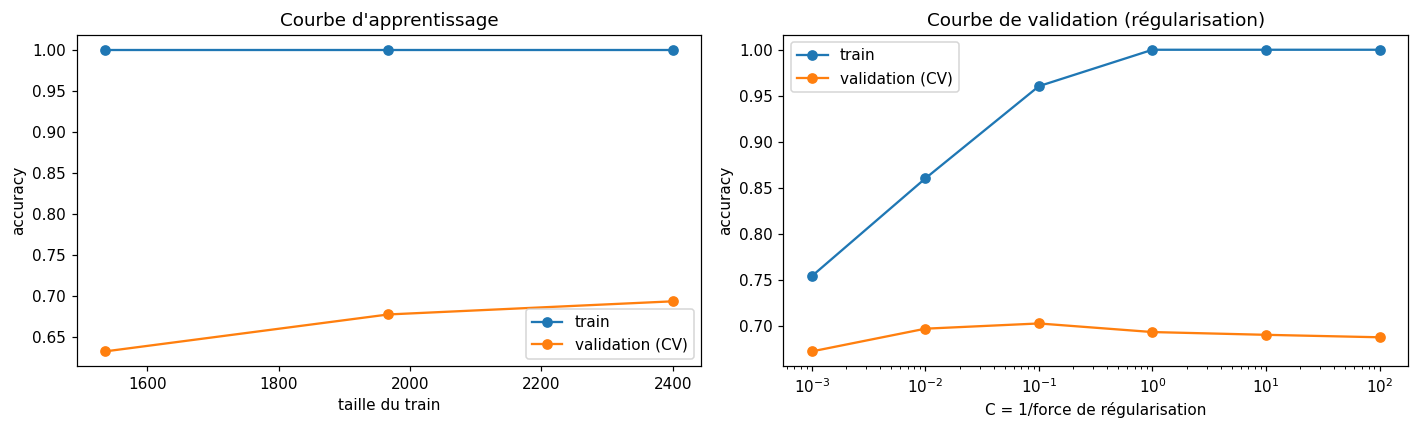

Meilleur C (max accuracy CV) : 0.1


In [13]:
# 1) Écart train vs test (sur/sous-apprentissage)
acc_tr = accuracy_score(y_train_raw, baseline.predict(Xtr_flat))
print(f"Accuracy train : {acc_tr:.3f} | test : {acc_ml:.3f} | écart : {acc_tr - acc_ml:+.3f}")

# Estimateur de référence (Ridge L2) pour les courbes
est = make_pipeline(StandardScaler(),
                    LogisticRegression(C=1.0, penalty="l2", solver="liblinear"))

# 2) Courbe d'apprentissage (biais/variance selon la taille du train)
sizes, tr_sc, cv_sc = learning_curve(
    est, Xtr_flat, y_train_raw, cv=5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)

# 3) Courbe de validation (effet de la régularisation C)
Cs = np.logspace(-3, 2, 6)
tr_c, cv_c = validation_curve(
    est, Xtr_flat, y_train_raw, param_name="logisticregression__C",
    param_range=Cs, cv=5, scoring="accuracy", n_jobs=-1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sizes, tr_sc.mean(1), "o-", label="train")
ax[0].plot(sizes, cv_sc.mean(1), "o-", label="validation (CV)")
ax[0].set_title("Courbe d'apprentissage"); ax[0].set_xlabel("taille du train")
ax[0].set_ylabel("accuracy"); ax[0].legend()

ax[1].plot(Cs, tr_c.mean(1), "o-", label="train")
ax[1].plot(Cs, cv_c.mean(1), "o-", label="validation (CV)")
ax[1].set_xscale("log"); ax[1].set_title("Courbe de validation (régularisation)")
ax[1].set_xlabel("C = 1/force de régularisation"); ax[1].set_ylabel("accuracy"); ax[1].legend()
plt.tight_layout(); plt.show()

best_C = Cs[cv_c.mean(1).argmax()]
print(f"Meilleur C (max accuracy CV) : {best_C:.3g}")

### 8.1 Lecture des courbes

Les chiffres parlent d'eux-mêmes : avec `C = 1`, la régression logistique obtient environ 0,98
d'accuracy en entraînement mais seulement 0,75 sur le test. Cet écart d'à peu près 0,23 est le signe
d'un surapprentissage : le modèle mémorise en partie ses 3072 pixels d'entrée. C'est donc un
problème de variance, pas de biais. La courbe de validation le confirme : quand `C` est grand (peu
de régularisation) le score d'entraînement grimpe mais la validation décroche ; en régularisant
davantage l'écart se referme, et le meilleur compromis se situe autour de `C = 0,1`. C'est
exactement là que Ridge, Lasso et ElasticNet jouent leur rôle, Lasso allant jusqu'à mettre à zéro
près de deux tiers des coefficients.

Même bien réglé, un modèle linéaire sur pixels bruts garde un plafond : il ne capte pas vraiment un
signal aussi local et texturé. Cette baseline donne donc une référence utile, ainsi qu'un diagnostic
clair sur ce qu'il faudra améliorer dans les prochaines itérations du projet.